THis is from book


In [144]:
class Card:
    FACES = ['Ace', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'Jack', 'Queen', 'King']
    SUITS = ['Hearts', 'Diamonds', 'Clubs', 'Spades']

    def __init__(self, face, suit):

        self._face = face
        self._suit = suit

    @property
    def face(self):
        return self._face

    @property
    def suit(self):
        return self._suit

    @property
    def image_name(self):

        return str(self).replace(' ','_') + '.png'

    def __repr__(self):
        return f"Card(face='{self.face}', suit = '{self.suit}')"

    def __format__(self, format):

        return f"{str(self) : {format}}"

In [145]:
t = Card('Ace', 'Diamond')

In [146]:
t

Card(face='Ace', suit = 'Diamond')

In [147]:
print(t)

Card(face='Ace', suit = 'Diamond')


In [148]:
t.face

'Ace'

In [149]:
t.face = 'a'

AttributeError: property 'face' of 'Card' object has no setter

In [150]:
f.face

NameError: name 'f' is not defined

In [151]:
t.face

'Ace'

In [152]:
t = Card('Ace', 'Diamond')

In [153]:
t

Card(face='Ace', suit = 'Diamond')

In [154]:
print(f"{t:>50}")

                Card(face='Ace', suit = 'Diamond')


In [155]:
import random

In [156]:
class DeckOfCards:

    NUMBER_OF_CARDS = 52

    def __init__(self):
        self.__current_card = 0
        self._deck = []

        for count in range(DeckOfCards.NUMBER_OF_CARDS):
            self._deck.append(Card(Card.FACES[count % 13],
                                   Card.SUITS[count // 13]))

In [157]:
def suffle(self):

    self._current_card = 0
    random.suffle(self._deck)

In [158]:
def deal_card(self):

    try:
        card = self._deck[self._current_card]
        self._current_card += 1
        return card
    except:
        return None

In [159]:
def __str__(self):
    s=''

    for index,card in enumerate(self._deck):
        s += f'{self._deck[index]:<19}'
        if (index + 1) % 4 == 0:
            s += '\n'

    return s

In [160]:
deck_of_card = DeckOfCards()

In [161]:
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [162]:
using matplotlib backend: Qt5Agg

SyntaxError: invalid syntax (4115962173.py, line 1)

In [163]:
from pathlib import Path

In [164]:
path = Path('.').joinpath('.card_images')

In [165]:
import matplotlib.pyplot as plt

In [166]:
import matplotlib.image as mpimg

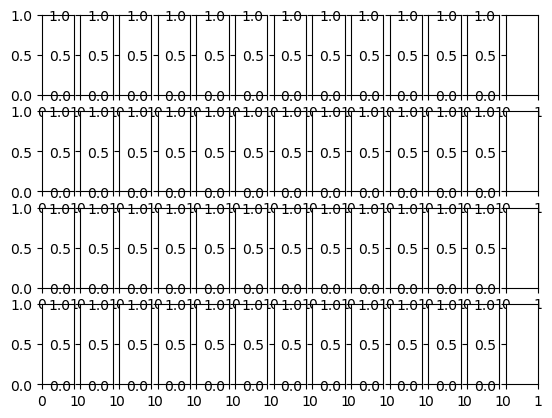

In [167]:
figure, axes_list = plt.subplots(nrows=4, ncols=13)

In [168]:
for axes in axes_list.ravel():
    axes.get_xaxis().set_visible(False)
    axes.get_yaxis().set_visible(False)
    image_name = deck_of_cards.deal_card().image_name
    img = mpimg.imread(str(path.joinpath(image_path).resolve()))
    axes.imshow(img)

AttributeError: 'Card' object has no attribute 'image_name'

In [169]:
deck_of_cards.deal_card().image_name


AttributeError: 'Card' object has no attribute 'image_name'

In [170]:
%recall 144-169

FileNotFoundError: [Errno 2] No such file or directory: '/home/crypticluminary/Documents/Python/card_images/4_Diamonds.png'

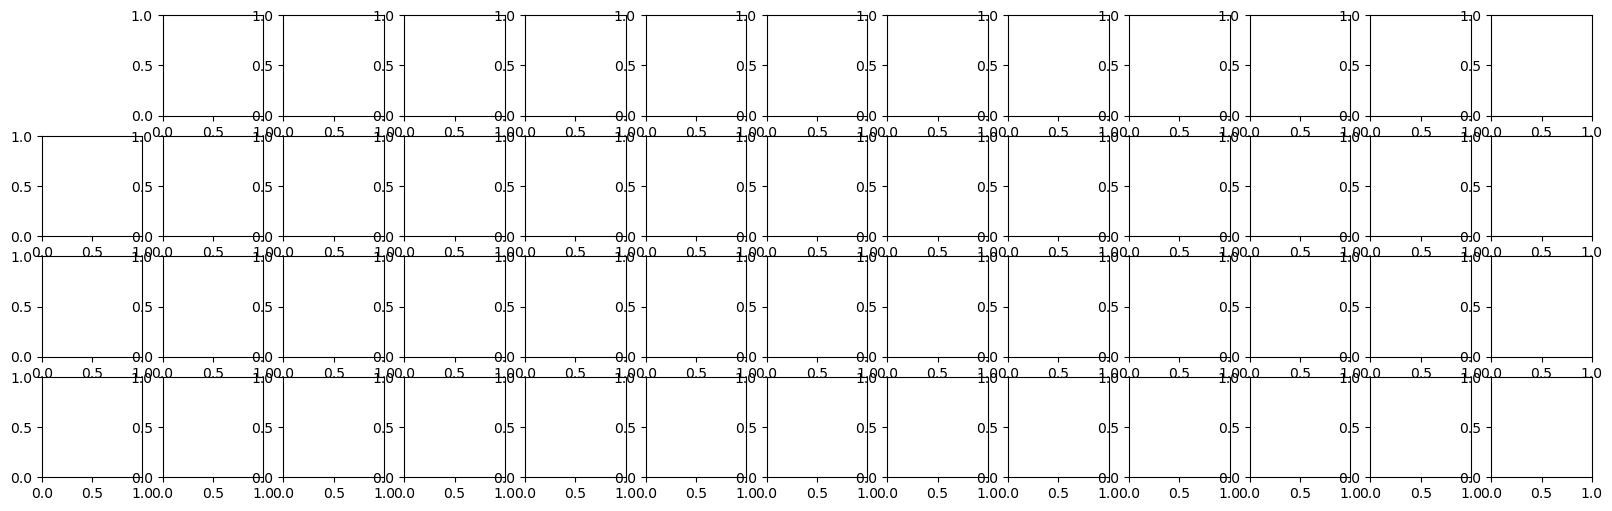

In [171]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Card class
class Card:
    FACES = ['Ace', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'Jack', 'Queen', 'King']
    SUITS = ['Hearts', 'Diamonds', 'Clubs', 'Spades']

    def __init__(self, face, suit):
        self._face = face
        self._suit = suit

    @property
    def face(self):
        return self._face

    @property
    def suit(self):
        return self._suit

    @property
    def image_name(self):
        return f"{self.face}_{self.suit}.png"

    def __repr__(self):
        return f"{self.face} of {self.suit}"

# Deck class
class DeckOfCards:
    NUMBER_OF_CARDS = 52

    def __init__(self):
        self._current_card = 0
        self._deck = [Card(Card.FACES[i % 13], Card.SUITS[i // 13]) for i in range(52)]

    def shuffle(self):
        self._current_card = 0
        random.shuffle(self._deck)

    def deal_card(self):
        if self._current_card >= len(self._deck):
            return None
        card = self._deck[self._current_card]
        self._current_card += 1
        return card

# Initialize
deck_of_cards = DeckOfCards()
deck_of_cards.shuffle()

# Path to images folder
path = Path('.').joinpath('card_images')  # make sure this folder exists

# Plotting
%matplotlib inline
fig, axes_list = plt.subplots(nrows=4, ncols=13, figsize=(20,6))
for ax in axes_list.ravel():
    ax.axis('off')
    card = deck_of_cards.deal_card()
    if card is not None:
        img = mpimg.imread(str(path.joinpath(card.image_name).resolve()))
        ax.imshow(img)
plt.show()


In [172]:
from pathlib import Path

path = Path('./card_images')

for file in path.iterdir():
    print(file.name)


English_pattern_playing_cards_deck.svg


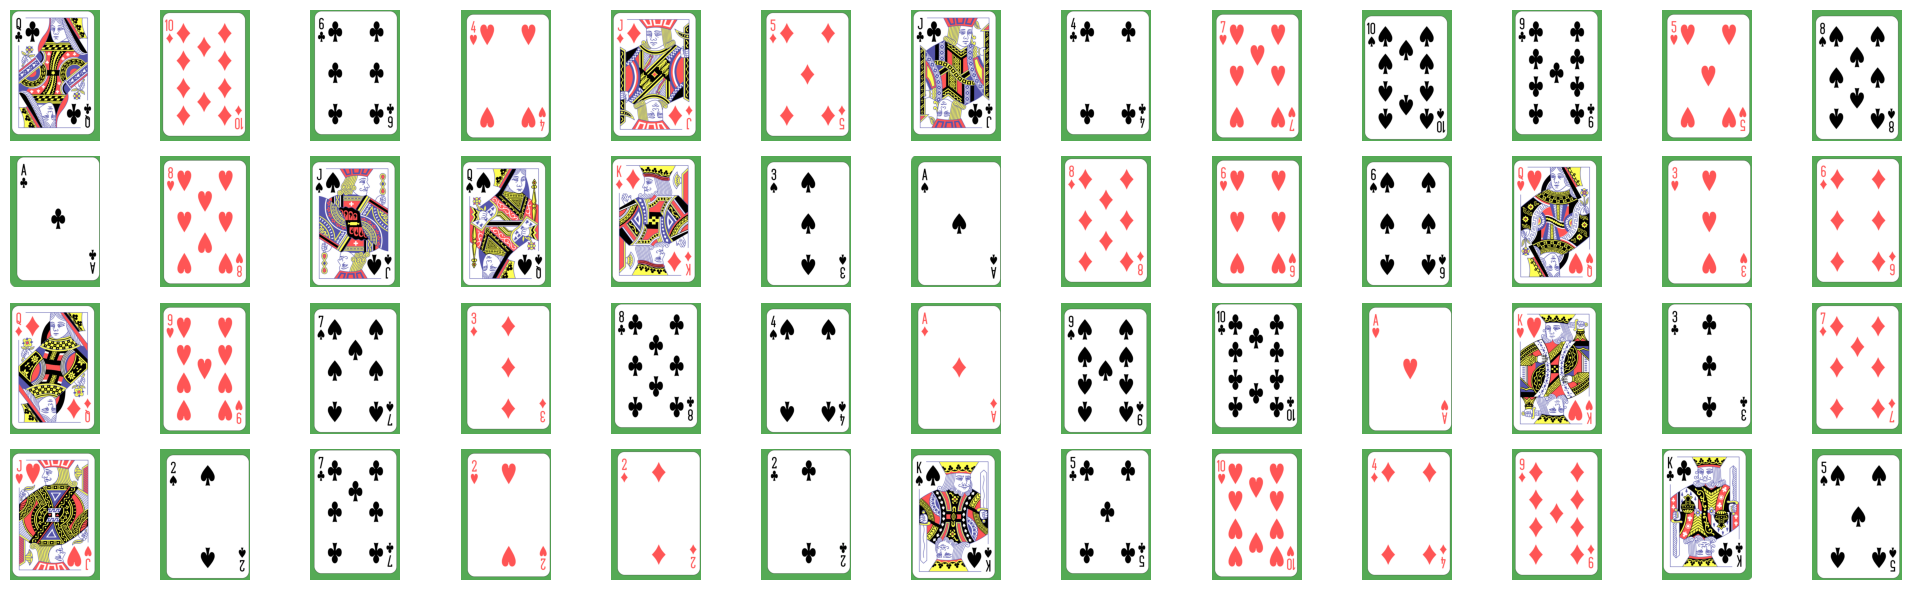

In [200]:
# ------------------------------
# Required Libraries
# ------------------------------
import cairosvg
from PIL import Image
import matplotlib.pyplot as plt
import random

# ------------------------------
# 1. Convert SVG to PNG
# ------------------------------
# Make sure your SVG file is in the same folder as this script
cairosvg.svg2png(url="English_pattern_playing_cards_deck.svg", write_to="deck.png")

# Open the PNG sprite sheet
deck_img = Image.open("deck.png")

# Determine card width and height
sheet_width, sheet_height = deck_img.size
CARD_WIDTH = sheet_width // 13    # 13 faces per row
CARD_HEIGHT = sheet_height // 4   # 4 suits per column

# ------------------------------
# 2. Function to crop card from sprite sheet
# ------------------------------
def get_card_image(face_index, suit_index):
    left = face_index * CARD_WIDTH
    top = suit_index * CARD_HEIGHT
    right = left + CARD_WIDTH
    bottom = top + CARD_HEIGHT
    return deck_img.crop((left, top, right, bottom))

# ------------------------------
# 3. Card Class
# ------------------------------
class Card:
    FACES = ['Ace','2','3','4','5','6','7','8','9','10','Jack','Queen','King']
    SUITS = ['Hearts','Diamonds','Clubs','Spades']

    def __init__(self, face, suit):
        self.face = face
        self.suit = suit

    def get_image(self):
        face_index = Card.FACES.index(self.face)
        suit_index = Card.SUITS.index(self.suit)
        return get_card_image(face_index, suit_index)

    def __repr__(self):
        return f"{self.face} to {self.suit}"

    
    def __str__(self):
        return f"{self.face} of {self.suit}" 

# ------------------------------
# 4. Deck of Cards Class
# ------------------------------
class DeckOfCards:
    def __init__(self):
        # Create all 52 cards
        self._deck = [Card(face, suit) for suit in Card.SUITS for face in Card.FACES]
        self._current_card = 0

    def shuffle(self):
        self._current_card = 0
        random.shuffle(self._deck)

    # def deal_card(self):
    #     if self._current_card >= len(self._deck):
    #         return None
    #     card = self._deck[self._current_card]
    #     self._current_card += 1
    #     return card

# ------------------------------
# 5. Initialize and shuffle deck
# ------------------------------
deck_of_cards = DeckOfCards()
deck_of_cards.shuffle()

# ------------------------------
# 6. Display all cards using Matplotlib
# ------------------------------
fig, axes = plt.subplots(4, 13, figsize=(20,6))

for ax, card in zip(axes.ravel(), deck_of_cards._deck):
    ax.imshow(card.get_image())
    ax.axis('off')

plt.tight_layout()
plt.show()


In [177]:
figure.tight_layout()

/tmp/ipykernel_13725/1210551376.py:1: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  figure.tight_layout()


In [179]:
deck_of_cards.shuffle()

In [180]:
for axes in axes_list.ravel():
    axes.get_xaxis().set_visible(False)
    axes.get_yaxis().set_visible(False)
    image_name = deck_of_cards.deal_card().image_name
    img = mpimg.imread(str(path.joinpath(image_path).resolve()))
    axes.imshow(img)

AttributeError: 'Card' object has no attribute 'image_name'

In [189]:
a = Card
a.face

AttributeError: type object 'Card' has no attribute 'face'

In [188]:
a.face

AttributeError: type object 'Card' has no attribute 'face'

In [197]:
c = DeckOfCards()
c._deck

[Ace to Hearts,
 2 to Hearts,
 3 to Hearts,
 4 to Hearts,
 5 to Hearts,
 6 to Hearts,
 7 to Hearts,
 8 to Hearts,
 9 to Hearts,
 10 to Hearts,
 Jack to Hearts,
 Queen to Hearts,
 King to Hearts,
 Ace to Diamonds,
 2 to Diamonds,
 3 to Diamonds,
 4 to Diamonds,
 5 to Diamonds,
 6 to Diamonds,
 7 to Diamonds,
 8 to Diamonds,
 9 to Diamonds,
 10 to Diamonds,
 Jack to Diamonds,
 Queen to Diamonds,
 King to Diamonds,
 Ace to Clubs,
 2 to Clubs,
 3 to Clubs,
 4 to Clubs,
 5 to Clubs,
 6 to Clubs,
 7 to Clubs,
 8 to Clubs,
 9 to Clubs,
 10 to Clubs,
 Jack to Clubs,
 Queen to Clubs,
 King to Clubs,
 Ace to Spades,
 2 to Spades,
 3 to Spades,
 4 to Spades,
 5 to Spades,
 6 to Spades,
 7 to Spades,
 8 to Spades,
 9 to Spades,
 10 to Spades,
 Jack to Spades,
 Queen to Spades,
 King to Spades]

In [192]:
c._deck

AttributeError: type object 'DeckOfCards' has no attribute '_deck'

        USING DEAL CARD FUNCTION
        

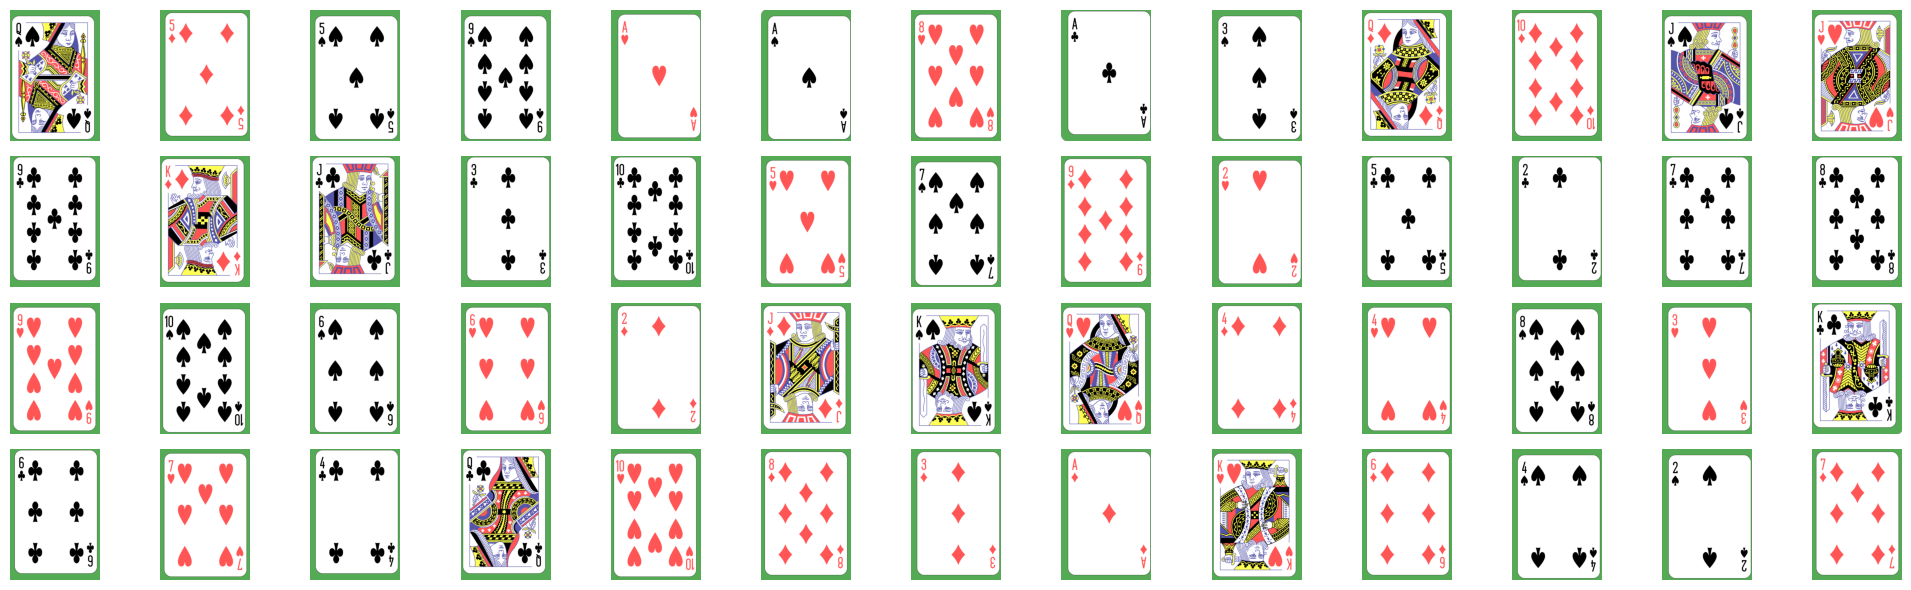

In [201]:
# ------------------------------
# Required Libraries
# ------------------------------
import cairosvg
from PIL import Image
import matplotlib.pyplot as plt
import random

# ------------------------------
# 1. Convert SVG to PNG
# ------------------------------
# Make sure your SVG file is in the same folder as this script
cairosvg.svg2png(url="English_pattern_playing_cards_deck.svg", write_to="deck.png")

# Open the PNG sprite sheet
deck_img = Image.open("deck.png")

# Determine card width and height
sheet_width, sheet_height = deck_img.size
CARD_WIDTH = sheet_width // 13    # 13 faces per row
CARD_HEIGHT = sheet_height // 4   # 4 suits per column

# ------------------------------
# 2. Function to crop card from sprite sheet
# ------------------------------
def get_card_image(face_index, suit_index):
    left = face_index * CARD_WIDTH
    top = suit_index * CARD_HEIGHT
    right = left + CARD_WIDTH
    bottom = top + CARD_HEIGHT
    return deck_img.crop((left, top, right, bottom))

# ------------------------------
# 3. Card Class
# ------------------------------
class Card:
    FACES = ['Ace','2','3','4','5','6','7','8','9','10','Jack','Queen','King']
    SUITS = ['Hearts','Diamonds','Clubs','Spades']

    def __init__(self, face, suit):
        self.face = face
        self.suit = suit

    def get_image(self):
        face_index = Card.FACES.index(self.face)
        suit_index = Card.SUITS.index(self.suit)
        return get_card_image(face_index, suit_index)

    def __repr__(self):
        return f"{self.face} to {self.suit}"

    def __str__(self):
        return f"{self.face} of {self.suit}" 

# ------------------------------
# 4. Deck of Cards Class
# ------------------------------
class DeckOfCards:
    def __init__(self):
        # Create all 52 cards
        self._deck = [Card(face, suit) for suit in Card.SUITS for face in Card.FACES]
        self._current_card = 0

    def shuffle(self):
        self._current_card = 0
        random.shuffle(self._deck)

    def deal_card(self):
        if self._current_card >= len(self._deck):
            return None
        card = self._deck[self._current_card]
        self._current_card += 1
        return card

# ------------------------------
# 5. Initialize and shuffle deck
# ------------------------------
deck_of_cards = DeckOfCards()
deck_of_cards.shuffle()

# ------------------------------
# 6. Display all cards using Matplotlib with deal_card()
# ------------------------------
fig, axes = plt.subplots(4, 13, figsize=(20,6))

for ax in axes.ravel():
    card = deck_of_cards.deal_card()   # <-- get one card at a time
    if card:                           # check if a card exists
        ax.imshow(card.get_image())
        ax.axis('off')

plt.tight_layout()
plt.show()


In [202]:
# ------------------------------
# Deal cards to multiple players
# ------------------------------

# Shuffle deck first
deck_of_cards.shuffle()

# Number of players and cards per player
num_players = 4
cards_per_player = 5

# Deal cards
players = [[] for _ in range(num_players)]

for _ in range(cards_per_player):
    for player_hand in players:
        card = deck_of_cards.deal_card()
        if card:
            player_hand.append(card)

# Print hands
for i, hand in enumerate(players, start=1):
    print(f"Player {i}'s hand:")
    for card in hand:
        print("  ", card)
    print()


Player 1's hand:
   Ace of Hearts
   8 of Hearts
   3 of Diamonds
   8 of Clubs
   3 of Hearts

Player 2's hand:
   4 of Spades
   2 of Hearts
   10 of Clubs
   Jack of Spades
   Ace of Spades

Player 3's hand:
   5 of Hearts
   6 of Clubs
   9 of Clubs
   3 of Clubs
   7 of Hearts

Player 4's hand:
   9 of Spades
   2 of Clubs
   King of Diamonds
   6 of Hearts
   Jack of Hearts



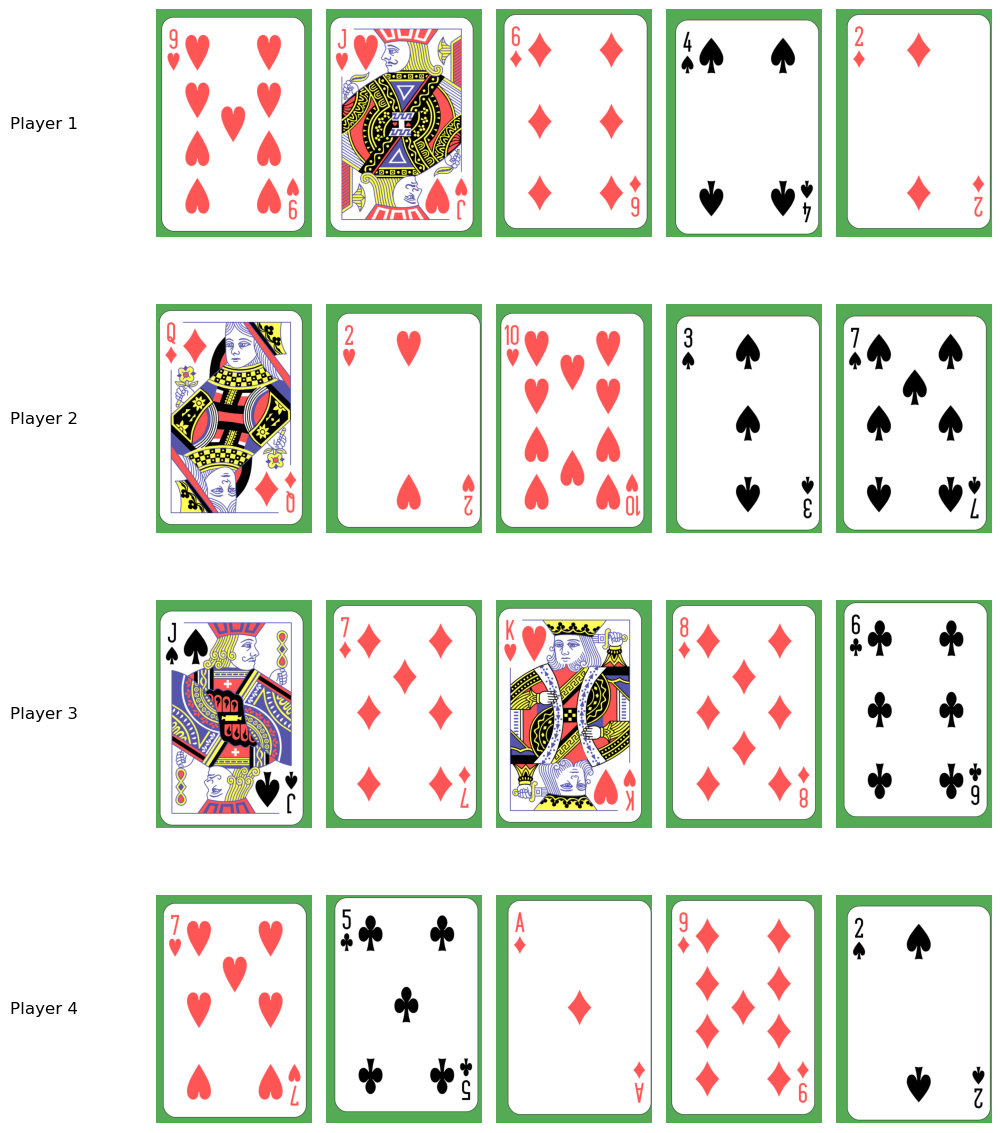

In [206]:
# ------------------------------
# Required Libraries
# ------------------------------
import cairosvg
from PIL import Image
import matplotlib.pyplot as plt
import random

# ------------------------------
# 1. Convert SVG to PNG
# ------------------------------
cairosvg.svg2png(url="English_pattern_playing_cards_deck.svg", write_to="deck.png")
deck_img = Image.open("deck.png")

sheet_width, sheet_height = deck_img.size
CARD_WIDTH = sheet_width // 13
CARD_HEIGHT = sheet_height // 4

# ------------------------------
# 2. Crop function
# ------------------------------
def get_card_image(face_index, suit_index):
    left = face_index * CARD_WIDTH
    top = suit_index * CARD_HEIGHT
    right = left + CARD_WIDTH
    bottom = top + CARD_HEIGHT
    return deck_img.crop((left, top, right, bottom))

# ------------------------------
# 3. Card class
# ------------------------------
class Card:
    FACES = ['Ace','2','3','4','5','6','7','8','9','10','Jack','Queen','King']
    SUITS = ['Hearts','Diamonds','Clubs','Spades']

    def __init__(self, face, suit):
        self.face = face
        self.suit = suit

    def get_image(self):
        face_index = Card.FACES.index(self.face)
        suit_index = Card.SUITS.index(self.suit)
        return get_card_image(face_index, suit_index)

    def __repr__(self):
        return f"{self.face} to {self.suit}"

# ------------------------------
# 4. Deck class
# ------------------------------
class DeckOfCards:
    def __init__(self):
        self._deck = [Card(face, suit) for suit in Card.SUITS for face in Card.FACES]
        self._current_card = 0

    def shuffle(self):
        self._current_card = 0
        random.shuffle(self._deck)

    def deal_card(self):
        if self._current_card >= len(self._deck):
            return None
        card = self._deck[self._current_card]
        self._current_card += 1
        return card

# ------------------------------
# 5. Initialize deck and shuffle
# ------------------------------
deck = DeckOfCards()
deck.shuffle()

# ------------------------------
# 6. Deal cards to 4 players
# ------------------------------
num_players = 4
cards_per_player = 5
players = [[] for _ in range(num_players)]

for _ in range(cards_per_player):
    for hand in players:
        card = deck.deal_card()
        if card:
            hand.append(card)

# ------------------------------
# Plot player hands with colored rows
# ------------------------------
fig, axes = plt.subplots(num_players, cards_per_player, figsize=(cards_per_player*2, num_players*3))

row_colors = ['#fdebd0', '#d6eaf8', '#d5f5e3', '#f9e79f']  # light colors for each player

for i, hand in enumerate(players):
    for j, card in enumerate(hand):
        ax = axes[i, j]
        # Fill background with color
        ax.set_facecolor(row_colors[i])
        # Show card image on top
        ax.imshow(card.get_image())
        ax.axis('off')
    # Add player label on the left of first card
    axes[i, 0].text(-0.5, 0.5, f"Player {i+1}", va='center', ha='right', fontsize=12, transform=axes[i, 0].transAxes)

plt.tight_layout()
plt.show()


